THIS IS JUST REPORT.QMD BUT IN .IPYNB FORM + new edits

# Distance Doesn't Explain Price
## How airline market power shapes what you pay

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML, display

PALETTE = ["#2166ac", "#4393c3", "#92c5de", "#f4a582", "#d6604d", "#b2182b"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

DATA = "../../assets/data"

scatter = pd.read_json(f"{DATA}/scatter_distance_fare.json")
r2 = json.load(open(f"{DATA}/r2_comparison.json"))
bubble = pd.read_json(f"{DATA}/hhi_bubble.json")
mono = pd.read_json(f"{DATA}/monopoly_routes.json")
airport_data = pd.read_json(f"{DATA}/airport_carriers.json")

## The Assumption We All Make

When buying a plane ticket, most of us assume the price reflects the journey — longer flight, higher fare. It's intuitive. It's also only half right.

Using four quarters of Bureau of Transportation Statistics ticketing data (Q3 2024 – Q2 2025), covering **25 million passenger records** across more than **80,000 routes**, we find that distance explains less than half of what you pay. The rest is something airlines rarely advertise: **market power**.

## Static View 1 — Does Distance Predict Fare?

Each dot below is a US airline route. Color shows how concentrated that route is — from competitive blue to near-monopoly red.

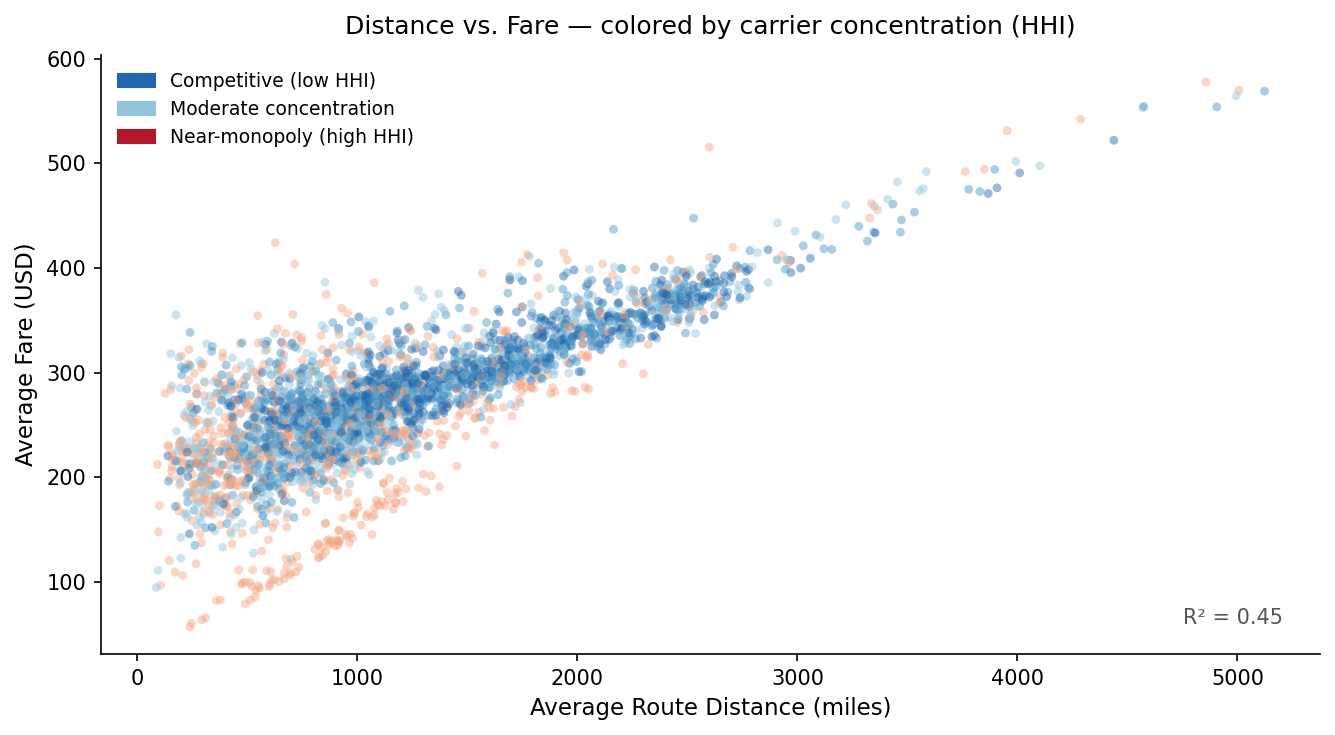

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

q = pd.qcut(scatter["HHI"], 4, labels=False)
colors = [PALETTE[int(v)] for v in q]

ax.scatter(
    scatter["AVG_DISTANCE"],
    scatter["AVG_FARE"],
    c=colors,
    alpha=0.45,
    s=18,
    linewidths=0
)

ax.set_xlabel("Average Route Distance (miles)", fontsize=11)
ax.set_ylabel("Average Fare (USD)", fontsize=11)
ax.set_title("Distance vs. Fare — colored by carrier concentration (HHI)", fontsize=12, pad=10)

ax.text(
    0.97,
    0.05,
    "R² = 0.45",
    transform=ax.transAxes,
    ha="right",
    fontsize=10,
    color="#555"
)

handles = [
    mpatches.Patch(color=PALETTE[0], label="Competitive (low HHI)"),
    mpatches.Patch(color=PALETTE[2], label="Moderate concentration"),
    mpatches.Patch(color=PALETTE[5], label="Near-monopoly (high HHI)"),
]

ax.legend(handles=handles, fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

Distance and fare move together — but the scatter is wide. Many short routes cost more than long ones. Notice the red dots, monopoly routes, clustering above the trend line.

In [3]:
## Static View 2 — How Much Does Each Factor Explain?

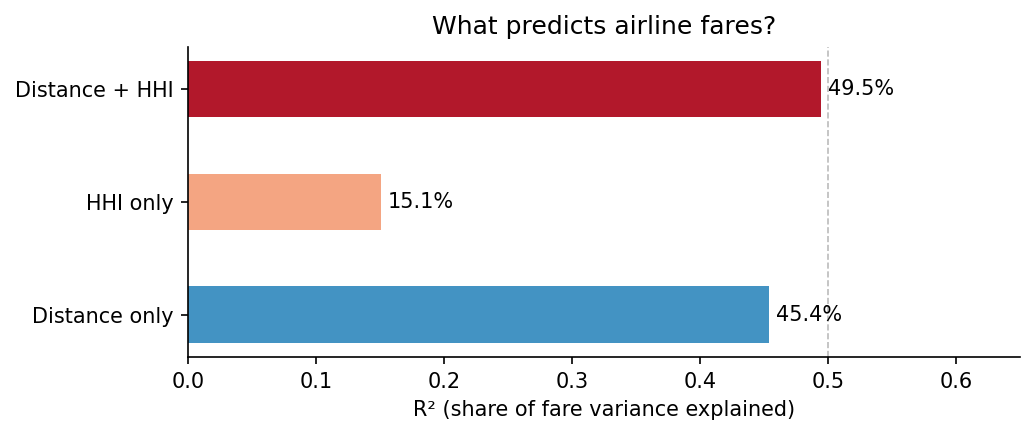

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))

labels = list(r2.keys())
values = list(r2.values())
bar_colors = [PALETTE[1], PALETTE[3], PALETTE[5]]

bars = ax.barh(labels, values, color=bar_colors, height=0.5)

for bar, val in zip(bars, values):
    ax.text(
        val + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}",
        va="center",
        fontsize=10
    )

ax.set_xlim(0, 0.65)
ax.set_xlabel("R² (share of fare variance explained)", fontsize=10)
ax.set_title("What predicts airline fares?", fontsize=12)
ax.axvline(0.5, color="#bbb", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

Distance alone explains **45%** of fare variance. Adding HHI bumps that to **49%**. HHI alone only explains **15%** — but that's because high-concentration routes also tend to be longer. The key finding: **even after accounting for distance, monopoly routes charge a systematic premium**.

## Interactive View 1 — Market Power vs. Fare

Explore every route: the further right a dot, the more one carrier dominates. Hover for details.

In [5]:
carrier_colors = {
    "WN": "#f4a582",
    "DL": "#2166ac",
    "AA": "#b2182b",
    "UA": "#4393c3",
    "AS": "#92c5de",
    "OO": "#d6604d",
    "MQ": "#762a83",
    "YX": "#1b7837",
    "B6": "#fddbc7",
    "HA": "#e08214",
}

bubble["COLOR"] = bubble["TOP_CARRIER"].map(carrier_colors).fillna("#aaa")
bubble["SIZE"] = np.sqrt(bubble["TOTAL_PASSENGERS"] / 500)

fig = px.scatter(
    bubble,
    x="HHI",
    y="AVG_FARE",
    size="SIZE",
    color="TOP_CARRIER",
    color_discrete_map=carrier_colors,
    hover_data={
        "ROUTE": True,
        "AVG_FARE": ":.0f",
        "HHI": ":.0f",
        "TOP_CARRIER_SHARE": ":.1%",
        "TOTAL_PASSENGERS": ":,"
    },
    labels={
        "HHI": "HHI (carrier concentration →)",
        "AVG_FARE": "Average Fare (USD)",
        "TOP_CARRIER": "Top Carrier"
    },
    title="Market Power vs. Fare"
)

fig.update_traces(marker=dict(opacity=0.6, line=dict(width=0.4, color="white")))

fig.update_layout(
    width=820,
    height=420,
    title_x=0.02
)

fig.show()

## Interactive View 2 — The Most Expensive Monopoly Routes

These 20 routes combine high fares with near-monopoly control. Hover to explore.

In [6]:
mono_sorted = mono.sort_values("AVG_FARE", ascending=True).copy()

fig = px.bar(
    mono_sorted,
    x="AVG_FARE",
    y="ROUTE",
    orientation="h",
    color="TOP_CARRIER",
    color_discrete_map=carrier_colors,
    hover_data={
        "AVG_FARE": ":.0f",
        "TOP_CARRIER_SHARE": ":.1%",
        "HHI": ":.0f"
    },
    labels={
        "AVG_FARE": "Average Fare (USD)",
        "ROUTE": "",
        "TOP_CARRIER": "Dominant Carrier"
    },
    title="Most Expensive Monopoly Routes"
)

fig.update_traces(
    text=mono_sorted["AVG_FARE"].round(0).astype(int).apply(lambda x: f"${x}"),
    textposition="outside"
)

fig.update_layout(
    width=820,
    height=420,
    title_x=0.02,
    xaxis_title="Average Fare (USD)",
    yaxis_title=None
)

fig.show()

## Linked View — Airport Dominance Map

Select an airport to see which carriers control departures from that city.

In [7]:
us_airports = airport_data[
    (airport_data["LON"] > -130) &
    (airport_data["LON"] < -60) &
    (airport_data["LAT"] > 24) &
    (airport_data["LAT"] < 50)
].copy()

us_airports.head()

,AIRPORT,LAT,LON,TOTAL_PAX,carriers
0,ABE,40.652100,-75.440804,22109,"[{'carrier': 'G4', 'share': 0.3755484192000000..."
1,ABI,32.411301,-99.681900,8070,"[{'carrier': 'MQ', 'share': 0.7206939281}, {'c..."
2,ABQ,35.040199,-106.609001,183240,"[{'carrier': 'WN', 'share': 0.5118805938000001..."
3,ABR,45.449100,-98.421799,1862,"[{'carrier': 'OO', 'share': 0.7422126745000001..."
4,ABY,31.535500,-84.194504,2687,"[{'carrier': 'OO', 'share': 0.6319315221}, {'c..."


In [9]:
import ipywidgets as widgets
from IPython.display import clear_output

airport_dropdown = widgets.Dropdown(
    options=sorted(us_airports["AIRPORT"].unique()),
    value="ATL",
    description="Airport:"
)

output = widgets.Output()

def show_airport_view(selected_airport):
    with output:
        clear_output(wait=True)

        selected_data = us_airports.copy()
        selected_data["SELECTED"] = selected_data["AIRPORT"] == selected_airport

        fig_map = px.scatter_geo(
            selected_data,
            lon="LON",
            lat="LAT",
            size=np.sqrt(selected_data["TOTAL_PAX"] / 200000),
            hover_name="AIRPORT",
            hover_data={"TOTAL_PAX": ":,"},
            scope="usa",
            title=f"Airport Dominance Map — {selected_airport}"
        )

        fig_map.update_layout(width=820, height=380)
        fig_map.show()

        airport_detail = us_airports[us_airports["AIRPORT"] == selected_airport].iloc[0]
        carriers = pd.DataFrame(airport_detail["carriers"])

        fig_bar = px.bar(
            carriers.sort_values("share", ascending=True),
            x="share",
            y="carrier",
            orientation="h",
            color="carrier",
            color_discrete_map=carrier_colors,
            text=carriers.sort_values("share", ascending=True)["share"].apply(lambda x: f"{x:.1%}"),
            labels={"share": "Passenger share", "carrier": "Carrier"},
            title=f"Carrier Market Share at {selected_airport}"
        )

        fig_bar.update_layout(
            width=820,
            height=260,
            xaxis_tickformat=".0%"
        )

        fig_bar.show()

def on_change(change):
    if change["name"] == "value":
        show_airport_view(change["new"])

airport_dropdown.observe(on_change)

display(airport_dropdown, output)
show_airport_view("ATL")

Dropdown(description='Airport:', index=21, options=('ABE', 'ABI', 'ABQ', 'ABR', 'ABY', 'ACK', 'ACT', 'ACV', 'A…

Output()

## Infographic — What Explains Your Ticket Price?

In [10]:
display(HTML("""
<div style="display:flex; gap:16px; flex-wrap:wrap; margin:2rem 0; font-family:sans-serif;">

  <div style="flex:1; min-width:160px; background:#2166ac; color:white; border-radius:10px; padding:24px 20px; text-align:center;">
    <div style="font-size:2.8rem; font-weight:700;">45%</div>
    <div style="font-size:1rem; margin-top:6px;">Distance</div>
    <div style="font-size:0.8rem; margin-top:8px; opacity:0.85;">Longer routes cost more — but not as much as you'd expect</div>
  </div>

  <div style="flex:1; min-width:160px; background:#d6604d; color:white; border-radius:10px; padding:24px 20px; text-align:center;">
    <div style="font-size:2.8rem; font-weight:700;">+4%</div>
    <div style="font-size:1rem; margin-top:6px;">Market Power</div>
    <div style="font-size:0.8rem; margin-top:8px; opacity:0.85;">Carrier concentration adds a premium on top of distance</div>
  </div>

  <div style="flex:1; min-width:160px; background:#555; color:white; border-radius:10px; padding:24px 20px; text-align:center;">
    <div style="font-size:2.8rem; font-weight:700;">51%</div>
    <div style="font-size:1rem; margin-top:6px;">Unexplained</div>
    <div style="font-size:0.8rem; margin-top:8px; opacity:0.85;">Seasonality, seat class, booking timing, fuel costs…</div>
  </div>

</div>

<div style="display:flex; gap:16px; flex-wrap:wrap; margin:1rem 0 2rem; font-family:sans-serif;">

  <div style="flex:1; min-width:200px; background:#f0f4f8; border-left:4px solid #2166ac; border-radius:6px; padding:16px 18px;">
    <div style="font-size:0.75rem; color:#666; text-transform:uppercase; letter-spacing:0.05em;">Most competitive route</div>
    <div style="font-size:1.3rem; font-weight:600; margin-top:4px;">ATL ↔ ORD</div>
    <div style="font-size:0.9rem; color:#444;">6 carriers · avg $178</div>
  </div>

  <div style="flex:1; min-width:200px; background:#f0f4f8; border-left:4px solid #b2182b; border-radius:6px; padding:16px 18px;">
    <div style="font-size:0.75rem; color:#666; text-transform:uppercase; letter-spacing:0.05em;">Worst monopoly route</div>
    <div style="font-size:1.3rem; font-weight:600; margin-top:4px;">EWR ↔ HNL</div>
    <div style="font-size:0.9rem; color:#444;">United 88% share · avg $570</div>
  </div>

</div>
"""))

## Data & Methods

Data: BTS DB1B Market, Q3 2024 – Q2 2025. Fares filtered to remove outliers using the IQR method and a price-per-mile floor. Carrier concentration is measured using the Herfindahl-Hirschman Index, or HHI, computed from passenger share per route. Regression is performed on log-transformed route-level average fares.

In [11]:
import json
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from ipywidgets import widgets, HBox, VBox, Output
from IPython.display import display, clear_output

# Load airport data
airport_data = pd.read_json(f"{DATA}/airport_carriers.json")

# Continental US only
us_airports = airport_data[
    (airport_data["LON"] > -130) &
    (airport_data["LON"] < -60) &
    (airport_data["LAT"] > 24) &
    (airport_data["LAT"] < 50)
].copy()

# Create a carrier-count variable
us_airports["CARRIER_COUNT"] = us_airports["carriers"].apply(len)

selected_airport = widgets.Dropdown(
    options=sorted(us_airports["AIRPORT"].unique()),
    value="ATL",
    description="Airport:"
)

out = Output()

def make_linked_airport_plot(airport):
    clear_output(wait=True)

    df = us_airports.copy()
    df["SELECTED"] = df["AIRPORT"] == airport

    selected_row = df[df["AIRPORT"] == airport].iloc[0]

    # ---------- Map ----------
    map_fig = go.Figure()

    map_fig.add_trace(
        go.Scattergeo(
            lon=df["LON"],
            lat=df["LAT"],
            text=df["AIRPORT"],
            mode="markers",
            marker=dict(
                size=np.sqrt(df["TOTAL_PAX"] / 200000),
                color=df["CARRIER_COUNT"],
                colorscale="Blues",
                colorbar=dict(title="Carrier #"),
                line=dict(width=0.5, color="white"),
                opacity=0.65
            ),
            customdata=df[["AIRPORT"]],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Carrier #: %{marker.color}<br>"
                "Passengers: %{marker.size:.1f}<extra></extra>"
            ),
            name="Airports"
        )
    )

    # Highlight selected airport on map
    map_fig.add_trace(
        go.Scattergeo(
            lon=[selected_row["LON"]],
            lat=[selected_row["LAT"]],
            text=[selected_row["AIRPORT"]],
            mode="markers",
            marker=dict(
                size=18,
                color="#b2182b",
                line=dict(width=2, color="white")
            ),
            hovertemplate="<b>%{text}</b><br>Selected airport<extra></extra>",
            name="Selected Airport"
        )
    )

    map_fig.update_layout(
        title=f"Airport Map — selected: {airport}",
        geo=dict(scope="usa", projection_type="albers usa"),
        width=820,
        height=430,
        margin=dict(l=10, r=10, t=50, b=10)
    )

    # ---------- Scatterplot ----------
    scatter_fig = go.Figure()

    scatter_fig.add_trace(
        go.Scatter(
            x=df["CARRIER_COUNT"],
            y=df["TOTAL_PAX"],
            text=df["AIRPORT"],
            mode="markers",
            marker=dict(
                size=10,
                color=np.where(df["SELECTED"], "#b2182b", "#4393c3"),
                opacity=np.where(df["SELECTED"], 1.0, 0.45),
                line=dict(width=np.where(df["SELECTED"], 2, 0.5), color="white")
            ),
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Carrier #: %{x}<br>"
                "Passengers: %{y:,}<extra></extra>"
            ),
            name="Airports"
        )
    )

    scatter_fig.update_layout(
        title=f"Carrier Count vs Passenger Volume — highlighted: {airport}",
        xaxis_title="Number of Carriers",
        yaxis_title="Total Passengers",
        width=820,
        height=430,
        margin=dict(l=60, r=20, t=50, b=50)
    )

    display(map_fig)
    display(scatter_fig)

def update_plot(change):
    with out:
        make_linked_airport_plot(change["new"])

selected_airport.observe(update_plot, names="value")

display(VBox([selected_airport, out]))

with out:
    make_linked_airport_plot(selected_airport.value)